In [ ]:
# IMPORT LIBRARIES
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

In [ ]:
# A function for web scraping

BASE_URL = "https://www.airlinequality.com/airline-reviews/british-airways"

def scrape_reviews(pages=30):
    reviews = []
    for page in range(1, pages + 1):
        url = f"{BASE_URL}/page/{page}/?sortby=post_date%3ADesc&pagesize=100"
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        soup = BeautifulSoup(response.content, "html.parser")
        
        for article in soup.find_all("article", itemprop="review"):
            reviews.append({
                "review_text": article.find("div", itemprop="reviewBody").get_text(strip=True),
                "rating": article.find("span", itemprop="ratingValue").get_text() if article.find("span", itemprop="ratingValue") else None,
                "date": article.find("time", itemprop="datePublished")["datetime"],
                "verified": "Trip Verified" in article.get_text()
            })
        time.sleep(2)  # be polite — respect rate limits
    return pd.DataFrame(reviews)

In [7]:
# RUN THE SCRAPER


# Call the function  defined in Cell 2
df = scrape_ba_reviews(max_pages=40)

# .shape returns (number of rows, number of columns)
# You should see something like (987, 5)
print(f"\nDataset shape: {df.shape}")

# .head() shows the first 5 rows so we can visually check the data looks right
df.head()

Scraping page 1 of 40...
  -> Got 100 reviews. Waiting 2.1s before next page...
Scraping page 2 of 40...
  -> Got 100 reviews. Waiting 3.6s before next page...
Scraping page 3 of 40...
  -> Got 100 reviews. Waiting 3.3s before next page...
Scraping page 4 of 40...
  -> Got 100 reviews. Waiting 2.8s before next page...
Scraping page 5 of 40...
  -> Got 100 reviews. Waiting 3.9s before next page...
Scraping page 6 of 40...
  -> Got 100 reviews. Waiting 3.6s before next page...
Scraping page 7 of 40...
  -> Got 100 reviews. Waiting 2.8s before next page...
Scraping page 8 of 40...
  -> Got 100 reviews. Waiting 2.2s before next page...
Scraping page 9 of 40...
  -> Got 100 reviews. Waiting 2.7s before next page...
Scraping page 10 of 40...
  -> Got 100 reviews. Waiting 3.5s before next page...
Scraping page 11 of 40...
  -> Got 100 reviews. Waiting 2.6s before next page...
Scraping page 12 of 40...
  -> Got 100 reviews. Waiting 2.3s before next page...
Scraping page 13 of 40...
  -> Got 10

,review_text,rating,date,verified,country
0,✅Trip Verified| I'm not entirely sure as to wh...,8.0,2026-05-02,True,T Bayne(United Kingdom)2nd May 2026
1,✅Trip Verified| Our first time in the new bu...,8.0,2026-04-21,True,Kevin Tunnicliffe(United Kingdom)21st April 2026
2,✅Trip Verified| Highly commendable again on ...,10.0,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026
3,✅Trip Verified| Highly commendable on all fr...,10.0,2026-04-09,True,Brian Crockford(United Kingdom)9th April 2026
4,Not Verified| Although the staff on board t...,2.0,2026-04-06,False,Sarah Harrison(United Kingdom)6th April 2026


In [12]:
# Save the data to a csv file
import os


# Save the DataFrame to a CSV file
df.to_csv("../data/raw_reviews.csv", index=False)

print(f"Saved {len(df)} reviews to data/raw_reviews.csv")

# .info() gives a summary of each column:
# - column name
# - how many non-null values it has
# - the data type (object = text, int64 = number, bool = True/False)
print("\nColumn summary:")
print(df.info())



Saved 4000 reviews to data/raw_reviews.csv

Column summary:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_text  4000 non-null   str    
 1   rating       3995 non-null   float64
 2   date         4000 non-null   str    
 3   verified     4000 non-null   bool   
 4   country      4000 non-null   str    
dtypes: bool(1), float64(1), str(3)
memory usage: 3.8 MB
None


In [ ]:
# Check out for missing values in the dataset
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
review_text    0
rating         5
date           0
verified       0
country        0
dtype: int64


In [14]:
print(f"\nVerified reviews: {df['verified'].sum()} out of {len(df)}")


Verified reviews: 1398 out of 4000


In [15]:
print("\nSample review text:")
print(df["review_text"].iloc[0])


Sample review text:
✅Trip Verified| I'm not entirely sure as to what they wish to achieve by reducing the seat pitch. I know it's a fairly short flight, but some of us are over 1.80mts tall. If you do online check-in at Vienna there is no 'bag drop' for hold luggage, so the option is fine if you're only carrying cabin baggage. And by the time the 'bag drop' counter is opened, the normal check-in desks are open anyway. As part of the frequent flyer programme, we will still use you (and associates), but please improve on the above issues.


In [ ]:
print("Rating distribution:")
print(df["rating"].value_counts().sort_index())

print(f"\nVerified vs unverified reviews:")
print(df["verified"].value_counts())

#print(f"\nTop 10 reviewer countries:")

#print(df["country"].value_counts().head(10)

Rating distribution:
rating
1.0     986
2.0     454
3.0     442
4.0     264
5.0     249
6.0     207
7.0     325
8.0     394
9.0     335
10.0    339
Name: count, dtype: int64

Verified vs unverified reviews:
verified
False    2602
True     1398
Name: count, dtype: int64


##  Visualize the Distribution

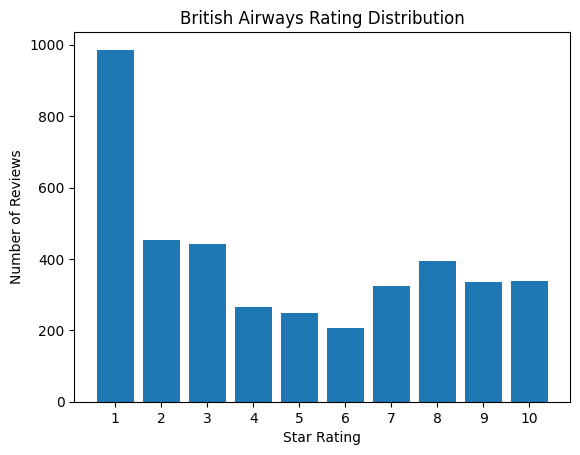

In [ ]:
import matplotlib.pyplot as plt

ratings = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
counts  = [986, 454, 442, 264, 249, 207, 325, 394, 335, 339]

plt.bar(ratings, counts)
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('British Airways Rating Distribution')
plt.xticks(ratings)
plt.show()